# Milan Airbnb and Rental Dynamics

The core question is whether the current geography of Airbnb activity in Milan helps us interpret the evolution of long term rents recorded by the official OMI datasets. The intended audience is a non expert reader who needs a clear path from raw files to interpretable evidence, not only a gallery of charts.

# 0) Import Libraries and Data

The first step is to import the necessary libraries for data manipulation and visualization, including pandas, matplotlib, and seaborn. After that, we define the main paths to import the raw data files and to store all the outputs of the notebook, which include the cleaned datasets and the visualizations.

In [1]:
# Import the libraries used across the notebook.
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Hide uninformative warnings during the exploratory workflow.
warnings.filterwarnings("ignore")

# Define the notebook and project paths.
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "src" else NOTEBOOK_DIR
DATA_DIR = PROJECT_ROOT / "Data"
SRC_DIR = PROJECT_ROOT / "src"

# Define the generated output folders requested for the assignment.
IO_DIR = SRC_DIR / "io"
CLEAN_DIR = IO_DIR / "cleaned_data"
PLOTS_DIR = IO_DIR / "plots"
RESULTS_DIR = IO_DIR / "results"
TABLEAU_DIR = IO_DIR / "tableau"

# Load the curated mapping utility used to bridge Airbnb neighbourhoods and OMI zones.
from utils.mappings import NEIGHBOURHOOD_TO_ZONA

# Create the folders before generating any file.
for folder in [IO_DIR, CLEAN_DIR, PLOTS_DIR, RESULTS_DIR, TABLEAU_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Save each table as both CSV and Excel.
def save_table_outputs(frame, csv_path, excel_path):
    frame.to_csv(csv_path, index=False)
    print("Saved:", csv_path)
    frame.to_excel(excel_path, index=False)
    print("Saved:", excel_path)

# Save the combined Tableau workbook.
def save_tableau_workbook(exports, workbook_path):
    with pd.ExcelWriter(workbook_path) as writer:
        for name, frame in exports.items():
            frame.to_excel(writer, sheet_name=name[:31], index=False)
    print("Saved:", workbook_path)


In order to create a cohesive narrative, we establish a shared visual language that uses the Milan palette chosen for the project. This palette is inspired by the colors of the city and helps us create a consistent look and feel across all our visualizations.

In [2]:
# Store the Milan palette in a reusable dictionary.
palette = {
    "coral": "#FF5A5F",
    "white": "#FFFFFF",
    "duomo_pink": "#E8B4B8",
    "red": "#D2232A",
    "gold": "#F4B82D",
    "green": "#1A5E3F",
    "terracotta": "#8B3A2F",
}

# Apply a clean plotting theme for the whole notebook.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.facecolor"] = palette["white"]
plt.rcParams["figure.facecolor"] = palette["white"]
plt.rcParams["axes.edgecolor"] = "#D9D9D9"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 10

The workflow begins with three raw sources. The Airbnb listings file describes the current market structure, the reviews file provides a real temporal signal of platform activity, and the semester based OMI files describe the rental market by zone from 2018 to 2024.

In [3]:
# Load the raw Airbnb listings and reviews files
print("Loading Airbnb datasets...")
listings_raw = pd.read_csv(DATA_DIR / "listings_milan.csv")
print(f"Loaded milan listings dataset with {len(listings_raw)} rows and {listings_raw.shape[1]} columns.")
reviews_raw = pd.read_csv(DATA_DIR / "reviews_milan.csv")
print(f"Loaded milan reviews dataset with {len(reviews_raw)} rows and {reviews_raw.shape[1]} columns.")
print("Airbnb datasets loaded successfully.")

print("---" * 20)
# Collect the raw OMI semester files in chronological order.
print("Loading OMI semester files...")
omi_files = sorted(DATA_DIR.glob("quotazioni_omi_locazione_*.csv"))
print(f"Loaded OMI semester files with {len(omi_files)} files.")

Loading Airbnb datasets...
Loaded milan listings dataset with 22948 rows and 18 columns.
Loaded milan reviews dataset with 981739 rows and 2 columns.
Airbnb datasets loaded successfully.
------------------------------------------------------------
Loading OMI semester files...
Loaded OMI semester files with 14 files.


The import step already clarifies the logic of the project. The listings table is a snapshot that describes the present structure of supply, while the reviews table is much larger and is better suited for temporal analysis. The OMI material is fragmented across fourteen semester files, which means that integration is not optional but central to the project itself. This distinction matters analytically. If we confuse a current snapshot with a genuine time series, we risk telling an attractive but unsupported story. For that reason the preprocessing stage keeps the snapshot logic of listings separate from the temporal logic of reviews and rents, and only later reconnects them through carefully defined aggregate tables.


# 1) Preprocessing

The preprocessing stage has two goals. The first goal is technical, because the raw files come in different formats, naming conventions, and levels of completeness. The second goal is interpretive, because the derived variables should already move the data closer to the questions we want to ask, such as how commercialized the Airbnb stock is, which listings behave like long term rentals, and how rents evolve across official market zones.

## 1.1) Preprocess Airbnb Listings

In [4]:
# Copy the raw listings table to preserve the original import
print("Cleaning the listings dataset...")
listings_clean = listings_raw.copy()

# Remove the empty group field that adds no information for Milan.
listings_clean = listings_clean.drop(columns=["neighbourhood_group"], errors="ignore")

# Standardize text fields used later in joins and plots.
for col in ["name", "host_name", "neighbourhood", "room_type", "license"]:
    listings_clean[col] = listings_clean[col].astype("string").str.strip()

# Normalize the neighborhood names to the style used by the mapping table.
listings_clean["neighbourhood"] = listings_clean["neighbourhood"].str.title()

# Parse the listing review date to a proper datetime field.
listings_clean["last_review"] = pd.to_datetime(listings_clean["last_review"], errors="coerce")

# Convert the numerical columns to a robust numeric dtype.
numeric_cols = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month", 
                "calculated_host_listings_count", "availability_365", "number_of_reviews_ltm", "latitude", "longitude"]
for col in numeric_cols:
    listings_clean[col] = pd.to_numeric(listings_clean[col], errors="coerce")

# Derive the core interpretation fields for later sections.
listings_clean["is_entire_home"] = listings_clean["room_type"].eq("Entire home/apt")
listings_clean["is_professional_host"] = listings_clean["calculated_host_listings_count"].ge(5)
listings_clean["is_long_term"] = listings_clean["minimum_nights"].ge(30)

# Derive activity and licensing signals from the snapshot.
listings_clean["is_active"] = listings_clean["number_of_reviews_ltm"].fillna(0).gt(0)
listings_clean["has_license"] = listings_clean["license"].notna()

# Derive a simple tier for host activity levels based on the number of listings they manage.
listings_clean["host_tier"] = "Unknown"
listings_clean.loc[listings_clean["calculated_host_listings_count"].eq(1), "host_tier"] = "1 listing"
listings_clean.loc[listings_clean["calculated_host_listings_count"].between(2, 5, inclusive="both"), "host_tier"] = "2-5 listings"
listings_clean.loc[listings_clean["calculated_host_listings_count"].between(6, 20, inclusive="both"), "host_tier"] = "6-20 listings"
listings_clean.loc[listings_clean["calculated_host_listings_count"].ge(21), "host_tier"] = "21+ listings"

# Derive a simple tier for minimum stay requirements.
listings_clean["nights_tier"] = "Unknown"
listings_clean.loc[listings_clean["minimum_nights"].between(1, 2, inclusive="both"), "nights_tier"] = "1-2 nights"
listings_clean.loc[listings_clean["minimum_nights"].between(3, 6, inclusive="both"), "nights_tier"] = "3-6 nights"
listings_clean.loc[listings_clean["minimum_nights"].between(7, 29, inclusive="both"), "nights_tier"] = "7-29 nights"
listings_clean.loc[listings_clean["minimum_nights"].ge(30), "nights_tier"] = "30+ nights"

# Distinguish formal codes from textual notes and missing licenses.
listings_clean["lic_category"] = "Missing"
listings_clean.loc[listings_clean["license"].str.startswith("IT", na=False), "lic_category"] = "Declared code"
listings_clean.loc[listings_clean["license"].notna() & ~listings_clean["license"].str.startswith("IT", na=False), "lic_category"] = "Text note"

# Drop useless columns that are not needed for the analysis or visualizations
columns_to_drop = ["host_name", "name", "license"]
listings_clean = listings_clean.drop(columns=columns_to_drop, errors="ignore")

# Save the cleaned listings table for the rest of the project.
listings_clean_path = CLEAN_DIR / "listings_milan_cleaned.csv"
listings_clean_excel_path = CLEAN_DIR / "listings_milan_cleaned.xlsx"
save_table_outputs(listings_clean, listings_clean_path, listings_clean_excel_path)
print("Listings dataset cleaned and saved successfully.")
print(f"Cleaned listings dataset has {len(listings_clean)} rows and {listings_clean.shape[1]} columns.")

Cleaning the listings dataset...
Saved: c:\Users\miche\University\Material\Data Science\Data Visualization\Project\src\io\cleaned_data\listings_milan_cleaned.csv
Saved: c:\Users\miche\University\Material\Data Science\Data Visualization\Project\src\io\cleaned_data\listings_milan_cleaned.xlsx
Listings dataset cleaned and saved successfully.
Cleaned listings dataset has 22948 rows and 22 columns.


Cleaning the listings file does more than make the table prettier. The derived variables expose the structure of the market. In particular, the share of entire homes and the share of multi listing hosts indicate that a large part of the Milan offer is not a marginal form of home sharing, but a more commercialized segment of the housing stock. That insight becomes important later, because the project is interested in pressure on ordinary residential use. It is also useful that we keep missing prices and licenses visible instead of forcing artificial fixes. Those gaps are not noise to hide. They tell us where the platform snapshot is incomplete, and they remind us that the cleaned file is an analytical convenience, not a claim that the underlying market is perfectly observed.

## 1.2) Preprocess Airbnb Reviews
The reviews file is the real backbone of the temporal analysis. It stretches from late 2010 to late 2025 and links almost one million observations to individual listings. This does not mean that reviews measure the whole platform perfectly, because unreviewed stays remain invisible, but it does mean that we have a much more defensible time signal than anything we could infer from the listing snapshot alone.
The preprocessing of the reviews file basically consists in only parsing the date field, which is the only one we need for the temporal analysis, as it is the only meningful variable in the file.

In [5]:
# Copy the raw reviews table before transforming it.
print("Cleaning the reviews dataset...")
reviews_clean = reviews_raw.copy()

# Parse the review date so that the file becomes a valid time series input.
reviews_clean["date"] = pd.to_datetime(reviews_clean["date"], errors="coerce")

# Remove exact duplicates and rows without a valid date.
reviews_clean = reviews_clean.drop_duplicates().dropna(subset=["date"]).copy()
print(f"Dropped {len(reviews_raw) - len(reviews_clean):,} duplicate or invalid rows from the reviews dataset.")

# Build explicit calendar fields for later aggregations.
reviews_clean["year"] = reviews_clean["date"].dt.year
reviews_clean["month"] = reviews_clean["date"].dt.month
reviews_clean["year_month"] = reviews_clean["date"].dt.to_period("M").astype(str)

# Save the cleaned reviews file to the notebook output area.
reviews_clean_path = CLEAN_DIR / "reviews_milan_cleaned.csv"
reviews_clean_excel_path = CLEAN_DIR / "reviews_milan_cleaned.xlsx"
save_table_outputs(reviews_clean, reviews_clean_path, reviews_clean_excel_path)
print("Reviews dataset cleaned and saved successfully.")
print(f"Cleaned reviews dataset has {len(reviews_clean)} rows and {reviews_clean.shape[1]} columns.")

Cleaning the reviews dataset...
Dropped 908 duplicate or invalid rows from the reviews dataset.
Saved: c:\Users\miche\University\Material\Data Science\Data Visualization\Project\src\io\cleaned_data\reviews_milan_cleaned.csv
Saved: c:\Users\miche\University\Material\Data Science\Data Visualization\Project\src\io\cleaned_data\reviews_milan_cleaned.xlsx
Reviews dataset cleaned and saved successfully.
Cleaned reviews dataset has 980831 rows and 5 columns.


Because review activity extends through the pandemic shock and the subsequent recovery, the dataset allows us to observe a structural break in platform use. That makes the temporal story more credible and gives the later visualizations a concrete event around which trends can be interpreted.

## 1.3) Preprocess OMI
The OMI integration step transforms a fragmented archive into a real panel. This is analytically valuable because it preserves the official spatial vocabulary of the rental market while also creating a stable yearly series that can be compared with Airbnb activity. The midpoint rent is especially useful here, because it compresses the lower and upper quotation bounds into one interpretable reference without discarding the original fields.

In [6]:
# Read and harmonize every OMI semester file.
omi_parts = []
for path in omi_files:
    year, semester = path.stem.replace("quotazioni_omi_locazione_", "").split("_")
    header_row = 1 if path.name == "quotazioni_omi_locazione_2023_1.csv" else 0
    part = pd.read_csv(path, sep=";", encoding="latin1", header=header_row)
    part["Year"] = int(year)
    part["Semester"] = int(semester)
    omi_parts.append(part)

# Concatenate the semester files into one long table.
omi_clean = pd.concat(omi_parts, ignore_index=True)

# Drop useless columns.
columns_to_drop = ["Area_territoriale", "Regione", "Prov", "Comune_amm", "Comune_descrizione", "Comune_ISTAT", "Comune_cat", "Sez", "Link_Zona"]
omi_clean = omi_clean.drop(columns=columns_to_drop, errors="ignore")
print(f"Dropped {len(columns_to_drop)} unnecessary columns from the OMI dataset.")

# Standardize text columns before any grouping step.
text_cols = ["Fascia", "Zona", "LinkZona", "Cod_Tip", "Descr_Tipologia", "Stato", "Stato_prev", "Sup_NL_loc"]
for col in text_cols:
    omi_clean[col] = omi_clean[col].astype("string").str.strip()

# Convert the rent columns from decimal comma to numeric values.
for col in ["Loc_min", "Loc_max"]:
    omi_clean[col] = pd.to_numeric(omi_clean[col].astype("string").str.replace(",", ".", regex=False), errors="coerce")

# Derive a midpoint rent to simplify comparisons across zones and years.
omi_clean["rent_mid"] = (omi_clean["Loc_min"] + omi_clean["Loc_max"]) / 2

# Retain only the residential categories that are directly relevant to the housing market.
residential_types = ["Abitazioni civili", "Abitazioni di tipo economico", "Abitazioni signorili", "Ville e Villini"]
omi_clean = omi_clean[omi_clean["Descr_Tipologia"].isin(residential_types)].copy()
print(f"Retained {len(residential_types)} residential OMI categories for the housing analysis.")

# Save the cleaned OMI panel for later use.
omi_clean_path = CLEAN_DIR / "omi_milan_cleaned.csv"
omi_clean_excel_path = CLEAN_DIR / "omi_milan_cleaned.xlsx"
save_table_outputs(omi_clean, omi_clean_path, omi_clean_excel_path)
print("OMI dataset cleaned and saved successfully.")
print(f"Cleaned OMI dataset has {len(omi_clean)} rows and {omi_clean.shape[1]} columns.")


Dropped 9 unnecessary columns from the OMI dataset.
Retained 4 residential OMI categories for the housing analysis.
Saved: c:\Users\miche\University\Material\Data Science\Data Visualization\Project\src\io\cleaned_data\omi_milan_cleaned.csv
Saved: c:\Users\miche\University\Material\Data Science\Data Visualization\Project\src\io\cleaned_data\omi_milan_cleaned.xlsx
OMI dataset cleaned and saved successfully.
Cleaned OMI dataset has 2423 rows and 13 columns.


At this stage the notebook retains only four residential categories from `Descr_Tipologia`: Abitazioni civili, Abitazioni di tipo economico, Abitazioni signorili, and Ville e Villini. The reasoning is substantive rather than cosmetic. The project is about the relationship between Airbnb and the long term housing market, so residential categories should remain in the panel while commercial and non residential categories such as shops, offices, garages, or warehouses should be excluded.

# 2) Mapping

The mapping step is necessary because the Airbnb and OMI datasets speak different spatial languages. Airbnb listings identify places through neighborhood names, while the OMI system organizes rents through official market zones called `Zona`. Without an explicit crosswalk, the two datasets can be described separately but not integrated in a way that supports neighborhood level interpretation.

The source of the mapping is the curated lookup table stored in `src/utils/mappings.py`. The notebook maps the `neighbourhood` field from the cleaned listings table to an `omi_zona` field, then uses that link to attach official rent levels to Airbnb snapshot metrics. This step is not a cosmetic merge. It is the bridge that allows the project to compare platform pressure with the formal geography of rents.

The mapping between Airbnb neighbourhoods and OMI zones has a many-to-one structure. This is explicit in the utility table, where several Airbnb neighbourhood labels are assigned to the same OMI zone code. In practical terms, this means that the Airbnb dataset uses a finer spatial partition, while the OMI dataset reports rental quotations on a broader official geography. The integration is therefore possible, but it also implies a loss of spatial detail when official OMI rent values are attached to Airbnb neighbourhoods.

In [7]:
# Measure mapping coverage without exporting any derived analytical table yet.
mapping_rows = listings_clean["neighbourhood"].map(NEIGHBOURHOOD_TO_ZONA)
mapping_lookup = listings_clean[["neighbourhood"]].dropna().drop_duplicates().copy()
mapping_lookup["omi_zona"] = mapping_lookup["neighbourhood"].map(NEIGHBOURHOOD_TO_ZONA)
mapped_neighbourhoods = int(mapping_lookup["neighbourhood"].nunique())
mapped_zones = int(mapping_lookup["omi_zona"].nunique())
mapping_match_rate = mapping_rows.notna().mean()
print("Evaluated neighbourhood to OMI zone coverage on the cleaned listings dataset.")
print(f"There are {mapped_zones} OMI zones and {mapped_neighbourhoods} neighborhoods represented in the lookup.")
print(f"Mapping match rate across listing rows: {mapping_match_rate:.1%}")


Evaluated neighbourhood to OMI zone coverage on the cleaned listings dataset.
There are 44 OMI zones and 87 neighborhoods represented in the lookup.
Mapping match rate across listing rows: 100.0%


The reassuring result here is that the lookup covers the full set of Milan neighbourhood labels present in the cleaned listings snapshot. This means the curated crosswalk is not a fragile patch but a reliable spatial bridge between the platform geography and the official geography of rents. That reliability matters because any missing assignment would create a blind spot exactly where the spatial argument of the project is strongest.

At the same time, the notebook deliberately stops at a coverage check in this section. No mapped analytical dataset is exported yet, because the aim up to this point is to work only with the three cleaned original sources. The actual dashboard oriented derivative tables are created later in the notebook, once the exploratory and narrative phases are complete.


# 3) EDA

The exploratory phase serves two complementary purposes. It documents the health of the data, and it identifies the patterns that are worth turning into final visual components. Before moving to the consolidated diagnostics, it is useful to inspect each main dataset in a very simple way. These first checks do not aim to prove anything sophisticated. They simply help the reader understand what kind of information each table contains and what its basic scale looks like.

To keep the process reproducible, the notebook writes tabular and textual summaries to `src/io/results` and stores the EDA figures in `src/io/plots`.

### 3.1) Listings Dataset

The Airbnb listings table is the most behaviorally rich source in the project. It contains the current structure of the platform in Milan, including prices, room types, host activity, and minimum stay rules. A first descriptive glance is enough to understand its scale and to see which fields will later matter for interpretation.

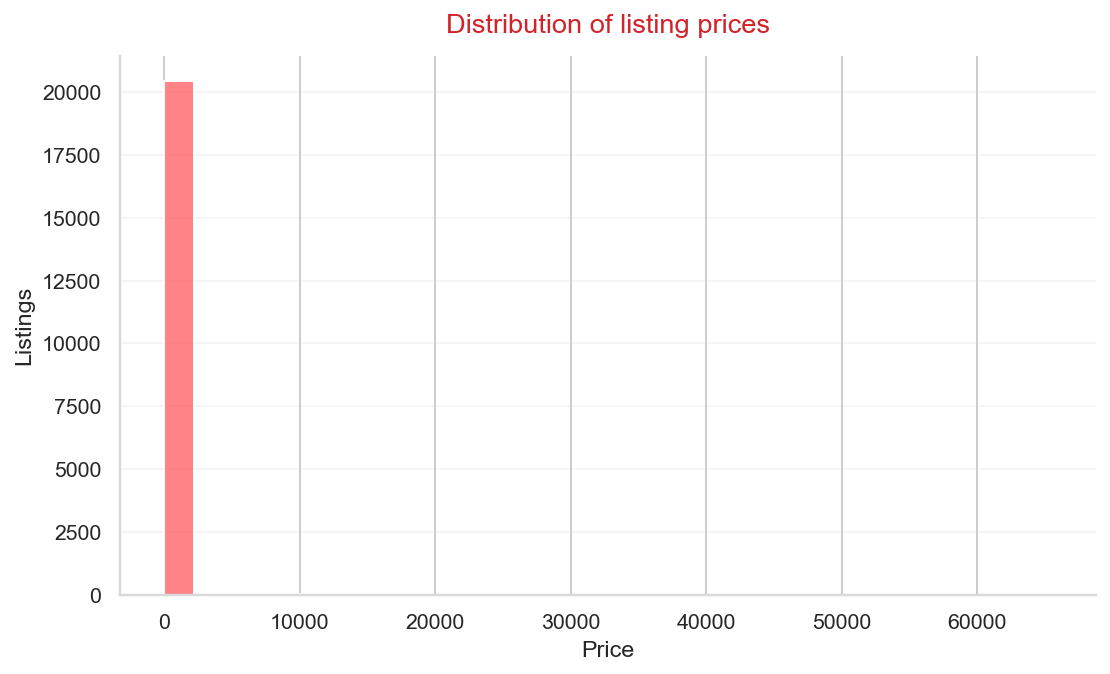

Saved: c:\Users\miche\University\Material\Data Science\Data Visualization\Project\src\io\plots\eda_listings_price_histogram.png


In [8]:
# Build a very simple histogram of listing prices in the cleaned listings table.
listings_price_plot = listings_clean["price"].dropna()

# Draw the plot with a simple distribution view of listing prices.
fig, ax = plt.subplots(figsize=(9, 5), facecolor=palette["white"])
sns.histplot(listings_price_plot, bins=30, ax=ax, color=palette["coral"], edgecolor=palette["white"])
ax.set_title("Distribution of listing prices", fontsize=14, color=palette["red"], pad=12)
ax.set_xlabel("Price")
ax.set_ylabel("Listings")
ax.grid(axis="y", alpha=0.2)

# Export the figure to the plots folder and show it in the notebook.
listings_eda_plot_path = PLOTS_DIR / "eda_listings_price_histogram.png"
fig.savefig(listings_eda_plot_path, bbox_inches="tight")
plt.show()
print("Saved:", listings_eda_plot_path)


### 3.2) Reviews Dataset

The reviews table is structurally simpler, but it is the only source that carries a long temporal history of Airbnb activity. This makes it especially valuable for trend analysis. A minimal description is enough to show how large the review archive is, how many listings it covers, and which time window it represents.

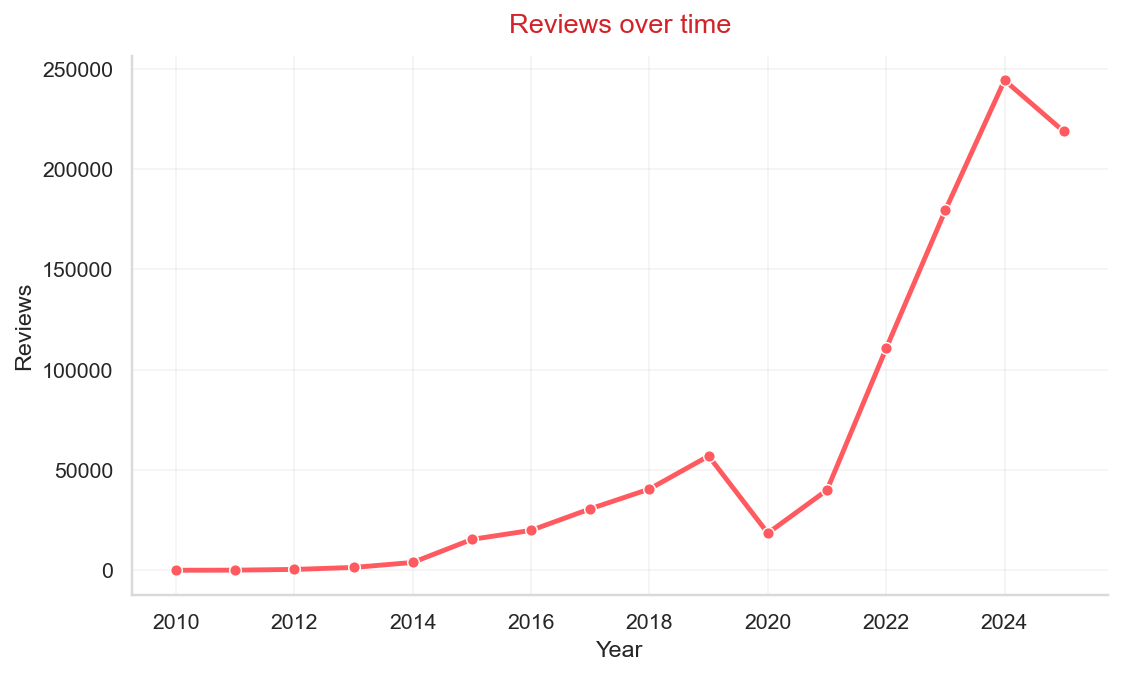

Saved: c:\Users\miche\University\Material\Data Science\Data Visualization\Project\src\io\plots\eda_reviews_over_time.png


In [9]:
# Build a very simple yearly count of Airbnb reviews.
reviews_year_plot = reviews_clean.groupby("year", as_index=False).agg(review_count=("listing_id", "size"))

# Draw the plot with a simple view of review volume over time.
fig, ax = plt.subplots(figsize=(9, 5), facecolor=palette["white"])
sns.lineplot(data=reviews_year_plot, x="year", y="review_count", ax=ax, color=palette["coral"], marker="o", linewidth=2.5)
ax.set_title("Reviews over time", fontsize=14, color=palette["red"], pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Reviews")
ax.grid(alpha=0.2)

# Export the figure to the plots folder and show it in the notebook.
reviews_eda_plot_path = PLOTS_DIR / "eda_reviews_over_time.png"
fig.savefig(reviews_eda_plot_path, bbox_inches="tight")
plt.show()
print("Saved:", reviews_eda_plot_path)


### 3.3) OMI Dataset

The OMI table is narrower than the Airbnb sources, but it is central because it represents the official rental market. After filtering it to the residential typologies relevant for this project, the dataset becomes easier to interpret. A simple summary clarifies how many zones, years, semesters, and residential categories remain in the analysis.

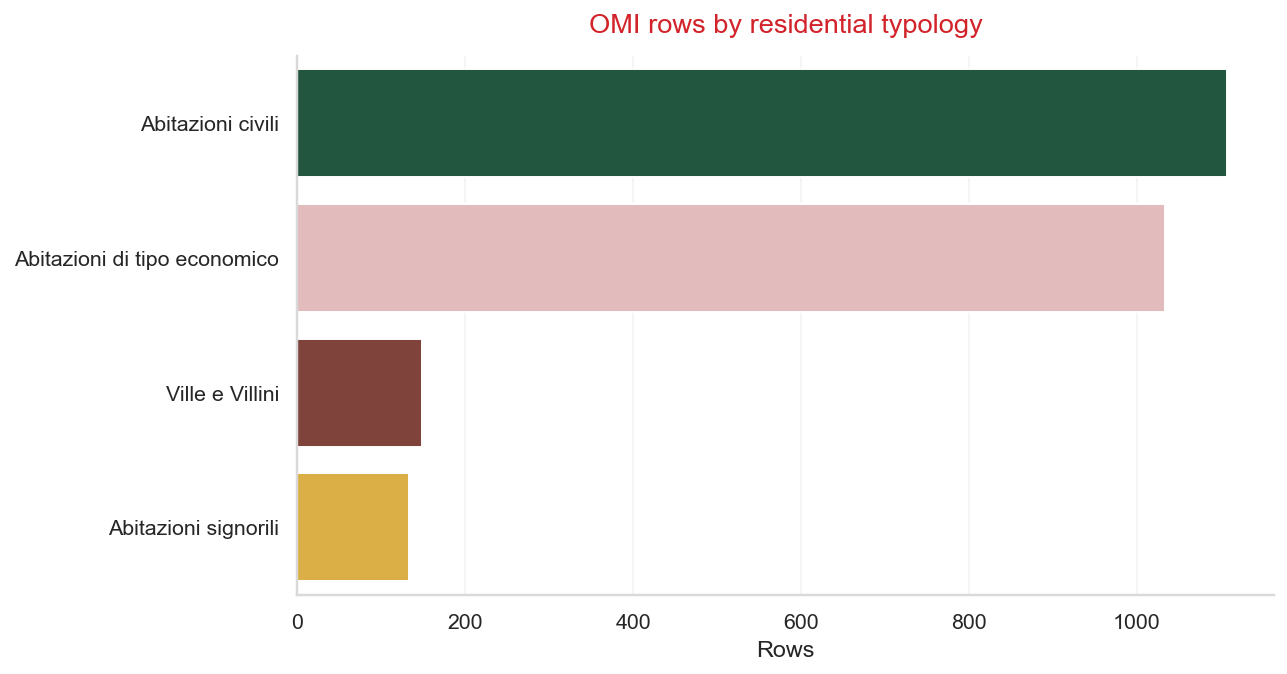

Saved: c:\Users\miche\University\Material\Data Science\Data Visualization\Project\src\io\plots\eda_omi_typologies.png


In [10]:
# Build a very simple count of rows by retained residential typology.
omi_type_plot = omi_clean["Descr_Tipologia"].value_counts().reset_index()
omi_type_plot.columns = ["typology", "count"]

# Draw the plot with a simple view of the retained OMI typologies.
fig, ax = plt.subplots(figsize=(9, 5), facecolor=palette["white"])
sns.barplot(data=omi_type_plot, x="count", y="typology", ax=ax, palette=[palette["green"], palette["duomo_pink"], palette["terracotta"], palette["gold"]])
ax.set_title("OMI rows by residential typology", fontsize=14, color=palette["red"], pad=12)
ax.set_xlabel("Rows")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.2)

# Export the figure to the plots folder and show it in the notebook.
omi_eda_plot_path = PLOTS_DIR / "eda_omi_typologies.png"
fig.savefig(omi_eda_plot_path, bbox_inches="tight")
plt.show()
print("Saved:", omi_eda_plot_path)


In [11]:
# Build a compact dictionary of cleaned datasets to profile.
eda_datasets = {}
eda_datasets["listings_clean"] = listings_clean
eda_datasets["reviews_clean"] = reviews_clean
eda_datasets["omi_clean"] = omi_clean

# Summarize rows, columns, and duplicated records for each cleaned table.
eda_overview = []
missing_frames = []
for name, frame in eda_datasets.items():
    eda_overview.append({"dataset": name, "rows": len(frame), "columns": frame.shape[1], "duplicate_rows": int(frame.duplicated().sum())})
    missing = frame.isna().sum().reset_index()
    missing.columns = ["column", "missing_values"]
    missing["dataset"] = name
    missing["missing_share"] = (missing["missing_values"] / len(frame)).round(4)
    missing_frames.append(missing.sort_values("missing_values", ascending=False).head(8))

# Combine the exploratory summaries into two compact tables.
eda_overview = pd.DataFrame(eda_overview)
eda_missing = pd.concat(missing_frames, ignore_index=True)

# Inspect key categorical structures so the report goes beyond missing values only.
eda_uniques = pd.DataFrame([
    {"dataset": "listings_clean", "column": "neighbourhood", "unique_values": listings_clean["neighbourhood"].nunique()},
    {"dataset": "listings_clean", "column": "room_type", "unique_values": listings_clean["room_type"].nunique()},
    {"dataset": "listings_clean", "column": "host_tier", "unique_values": listings_clean["host_tier"].nunique()},
    {"dataset": "listings_clean", "column": "nights_tier", "unique_values": listings_clean["nights_tier"].nunique()},
    {"dataset": "listings_clean", "column": "lic_category", "unique_values": listings_clean["lic_category"].nunique()},
    {"dataset": "reviews_clean", "column": "listing_id", "unique_values": reviews_clean["listing_id"].nunique()},
    {"dataset": "reviews_clean", "column": "year", "unique_values": reviews_clean["year"].nunique()},
    {"dataset": "omi_clean", "column": "Descr_Tipologia", "unique_values": omi_clean["Descr_Tipologia"].nunique()},
    {"dataset": "omi_clean", "column": "Stato", "unique_values": omi_clean["Stato"].nunique()},
    {"dataset": "omi_clean", "column": "Zona", "unique_values": omi_clean["Zona"].nunique()},
])

# Build cross-dataset highlights for the textual report.
room_type_counts = listings_clean["room_type"].value_counts(dropna=False)
host_tier_counts = listings_clean["host_tier"].value_counts(dropna=False)
lic_category_counts = listings_clean["lic_category"].value_counts(dropna=False)
review_year_counts = reviews_clean["year"].value_counts().sort_index()
omi_type_counts = omi_clean["Descr_Tipologia"].value_counts(dropna=False)
state_counts = omi_clean["Stato"].value_counts(dropna=False)
top_neighbourhoods = listings_clean.groupby("neighbourhood", as_index=False).agg(listings_count=("id", "nunique")).sort_values("listings_count", ascending=False).head(10)
mapped_neighbourhood_share = int(listings_clean["neighbourhood"].dropna().nunique())
mapped_zone_share = int(listings_clean["neighbourhood"].map(NEIGHBOURHOOD_TO_ZONA).nunique())


To summarize the results in a readable format, the notebook writes a textual report to `src/io/results`. The report highlights the key patterns in the data, such as the number of observations, missing values, and the distribution of key variables. This report serves as a reference for the later stages of the project, where we will build visualizations based on these insights.

In [12]:
# Write a reproducible text report for the submission folder.
report_lines = []
report_lines.append("Milan Airbnb and Rental Dynamics - EDA report")
report_lines.append("=" * 72)
report_lines.append("")
report_lines.append(f"Listings cleaned: {len(listings_clean):,} rows and {listings_clean.shape[1]} columns.")
report_lines.append(f"Reviews cleaned: {len(reviews_clean):,} rows and {reviews_clean.shape[1]} columns.")
report_lines.append(f"OMI cleaned: {len(omi_clean):,} rows and {omi_clean.shape[1]} columns.")
report_lines.append("")
report_lines.append("Mapping highlights")
report_lines.append(f"Mapped neighbourhood labels in the Airbnb snapshot: {mapped_neighbourhood_share}")
report_lines.append(f"Mapped OMI zones implied by the lookup: {mapped_zone_share}")
report_lines.append(f"The many to one mapping compresses {mapped_neighbourhood_share} neighbourhood labels into {mapped_zone_share} official OMI zones.")
report_lines.append("")
report_lines.append("Listings highlights")
report_lines.append(f"Entire home share: {listings_clean['is_entire_home'].mean():.1%}")
report_lines.append(f"Professional host share: {listings_clean['is_professional_host'].mean():.1%}")
report_lines.append(f"Missing price share: {listings_clean['price'].isna().mean():.1%}")
report_lines.append("")
report_lines.append("Reviews highlights")
report_lines.append(f"Unique reviewed listings: {reviews_clean['listing_id'].nunique():,}")
report_lines.append(f"Review window: {reviews_clean['date'].min().date()} to {reviews_clean['date'].max().date()}")
report_lines.append(f"Peak review year in the cleaned history: {int(review_year_counts.idxmax())}")
report_lines.append("")
report_lines.append("OMI highlights")
report_lines.append(f"Covered years: {omi_clean['Year'].min()} to {omi_clean['Year'].max()}")
report_lines.append(f"Residential OMI typologies retained: {omi_clean['Descr_Tipologia'].nunique()}")
report_lines.append(f"Unique OMI zones: {omi_clean['Zona'].nunique()}")
report_lines.append(f"Average midpoint rent in the cleaned panel: {omi_clean['rent_mid'].mean():.2f}")
report_lines.append("")
report_lines.append("Room types")
for label, value in room_type_counts.items():
    report_lines.append(f"{label}: {int(value):,}")
report_lines.append("")
report_lines.append("Host tiers")
for label, value in host_tier_counts.items():
    report_lines.append(f"{label}: {int(value):,}")
report_lines.append("")
report_lines.append("License categories")
for label, value in lic_category_counts.items():
    report_lines.append(f"{label}: {int(value):,}")
report_lines.append("")
report_lines.append("Retained OMI residential typologies")
for label, value in omi_type_counts.items():
    report_lines.append(f"{label}: {int(value):,} rows")
report_lines.append("")
report_lines.append("OMI quality states")
for label, value in state_counts.items():
    report_lines.append(f"{label}: {int(value):,} rows")
report_lines.append("")
report_lines.append("Top Airbnb neighbourhoods by listing count")
for row in top_neighbourhoods.itertuples(index=False):
    report_lines.append(f"{row.neighbourhood}: {int(row.listings_count):,} listings")
report_lines.append("")
eda_report_path = RESULTS_DIR / "eda_report.txt"
eda_report_path.write_text("\n".join(report_lines), encoding="utf-8")
eda_overview.to_csv(RESULTS_DIR / "eda_overview.csv", index=False)
eda_missing.to_csv(RESULTS_DIR / "eda_missingness_top8.csv", index=False)
eda_uniques.to_csv(RESULTS_DIR / "eda_unique_values.csv", index=False)
print("EDA report and summaries saved successfully.")


EDA report and summaries saved successfully.


The exploratory summaries show that the datasets are not equally informative, and that difference is itself an insight. The listings file is wide and behaviorally rich, but it is only a snapshot. The reviews file is narrower, yet it carries the strongest temporal signal. The OMI panel is smaller than both, but it is the only source that speaks directly about the formal rent market. The project becomes persuasive only when these strengths are combined instead of treated as interchangeable.

The EDA also reveals a strong concentration inside the cleaned Airbnb snapshot itself. A limited set of neighbourhoods absorbs a large share of the current stock, which already suggests that platform intensity is not spread evenly across Milan. The mapping step will later translate that uneven geography into official OMI zones, but at this stage the visual analysis still relies only on the cleaned original tables.

# 4) Overview - Visualization

The next figure is designed for a reader who may know Milan but not the datasets. The aim is to give one intuitive entry point into the project by combining current offer structure, neighbourhood concentration, and the citywide temporal comparison between Airbnb review activity and official rent levels. This overview does not try to answer every analytical question. It creates the mental map needed to read the more pointed visualizations that follow.


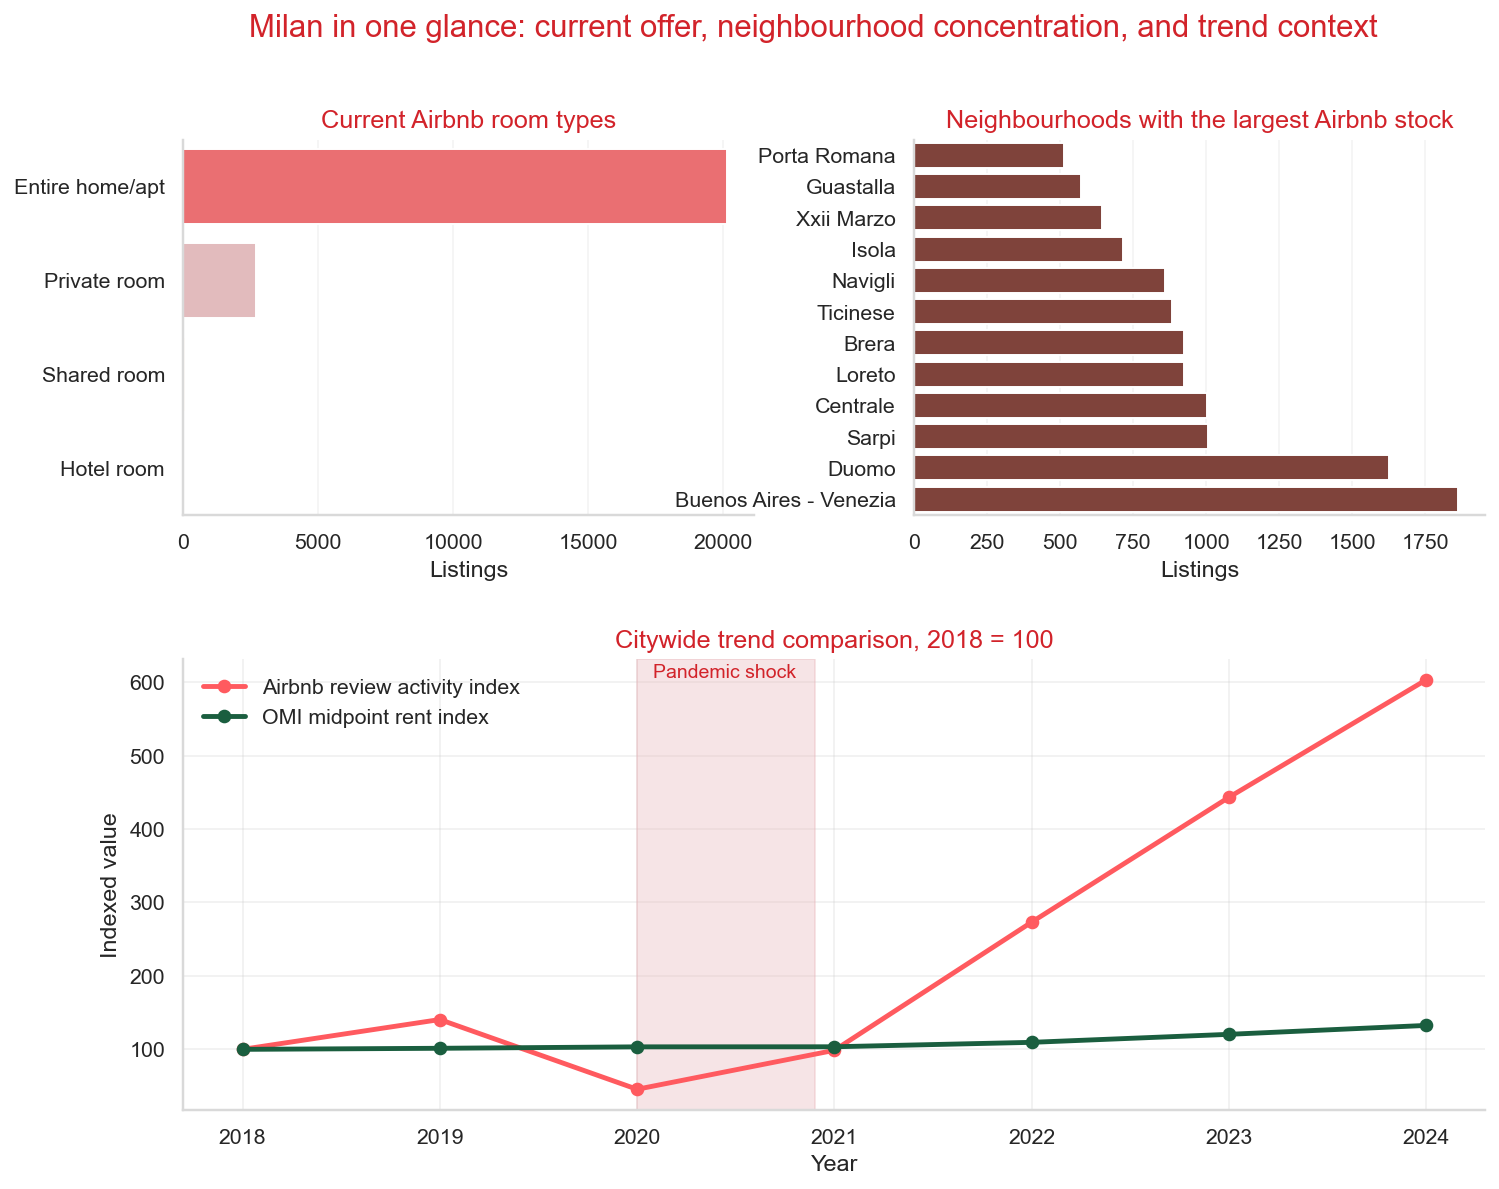

Saved: c:\Users\miche\University\Material\Data Science\Data Visualization\Project\src\io\plots\overview_visualization.png


In [13]:
# Aggregate citywide review activity directly from the cleaned reviews table.
reviews_yearly = reviews_clean.groupby("year", as_index=False).agg(review_count=("listing_id", "size"))
reviews_yearly = reviews_yearly[reviews_yearly["year"].between(2018, 2024)].copy()

# Aggregate citywide official rents directly from the cleaned OMI panel.
omi_yearly_overview = omi_clean.groupby("Year", as_index=False).agg(rent_mid=("rent_mid", "mean"))
omi_yearly_overview = omi_yearly_overview[omi_yearly_overview["Year"].between(2018, 2024)].copy()

# Build simple current structure summaries from the cleaned listings table.
room_mix = listings_clean["room_type"].value_counts().reset_index()
room_mix.columns = ["room_type", "count"]
top12_neighbourhoods = listings_clean.groupby("neighbourhood", as_index=False).agg(listings_count=("id", "nunique")).sort_values("listings_count", ascending=False).head(12).sort_values("listings_count")

# Normalize the two citywide yearly series to the same baseline for readability.
overview_yearly = reviews_yearly.merge(omi_yearly_overview, left_on="year", right_on="Year", how="inner")
overview_yearly["reviews_index"] = overview_yearly["review_count"] / overview_yearly["review_count"].iloc[0] * 100
overview_yearly["rent_index"] = overview_yearly["rent_mid"] / overview_yearly["rent_mid"].iloc[0] * 100

# Arrange the overview into a compact dashboard style figure.
fig = plt.figure(figsize=(12, 9), facecolor=palette["white"])
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2], hspace=0.35, wspace=0.28)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

# Plot the current Airbnb room type structure.
sns.barplot(data=room_mix, x="count", y="room_type", ax=ax1, palette=[palette["coral"], palette["duomo_pink"], palette["gold"], palette["green"]])
ax1.set_title("Current Airbnb room types", fontsize=13, color=palette["red"])
ax1.set_xlabel("Listings")
ax1.set_ylabel("")
ax1.grid(axis="x", alpha=0.2)

# Plot the neighbourhoods with the highest current Airbnb stock.
sns.barplot(data=top12_neighbourhoods, x="listings_count", y="neighbourhood", ax=ax2, color=palette["terracotta"])
ax2.set_title("Neighbourhoods with the largest Airbnb stock", fontsize=13, color=palette["red"])
ax2.set_xlabel("Listings")
ax2.set_ylabel("")
ax2.grid(axis="x", alpha=0.2)

# Plot the indexed citywide temporal comparison on the bottom row.
ax3.plot(overview_yearly["year"], overview_yearly["reviews_index"], color=palette["coral"], marker="o", linewidth=2.5, label="Airbnb review activity index")
ax3.plot(overview_yearly["year"], overview_yearly["rent_index"], color=palette["green"], marker="o", linewidth=2.5, label="OMI midpoint rent index")
ax3.axvspan(2020, 2020.9, color=palette["duomo_pink"], alpha=0.35)
ax3.text(2020.08, ax3.get_ylim()[1] * 0.96, "Pandemic shock", color=palette["red"], fontsize=10)
ax3.set_title("Citywide trend comparison, 2018 = 100", fontsize=13, color=palette["red"])
ax3.set_xlabel("Year")
ax3.set_ylabel("Indexed value")
ax3.legend(frameon=False, loc="upper left")
ax3.grid(alpha=0.25)

# Add a narrative title and export the figure.
fig.suptitle("Milan in one glance: current offer, neighbourhood concentration, and trend context", fontsize=16, color=palette["red"], y=0.98)
overview_plot_path = PLOTS_DIR / "overview_visualization.png"
fig.savefig(overview_plot_path, bbox_inches="tight")
plt.show()
print("Saved:", overview_plot_path)


The overview makes three patterns legible at once. First, entire homes dominate the current Airbnb offer, which strengthens the idea that the platform is closely tied to the use of full residential units rather than only spare rooms. Second, the stock is strongly concentrated in a subset of neighbourhoods, which means any discussion of pressure should be spatial rather than purely citywide. Third, review activity and official rents both recover after the pandemic, although they do so with different intensity, suggesting that the two systems are related but not mechanically identical.

This is the kind of summary a non expert reader needs. It avoids technical overload, but it still conveys that the project is about structure, concentration, and temporal context, not about a simplistic one variable explanation of urban change.


# 5) Black Hat Visualization

A black hat view should use the same data but manipulate perception through design choices. The aim is not to produce false numbers, but to show how a chart can become misleading when it hides uncertainty, truncates context, and invites an emotional conclusion that the evidence does not actually justify.


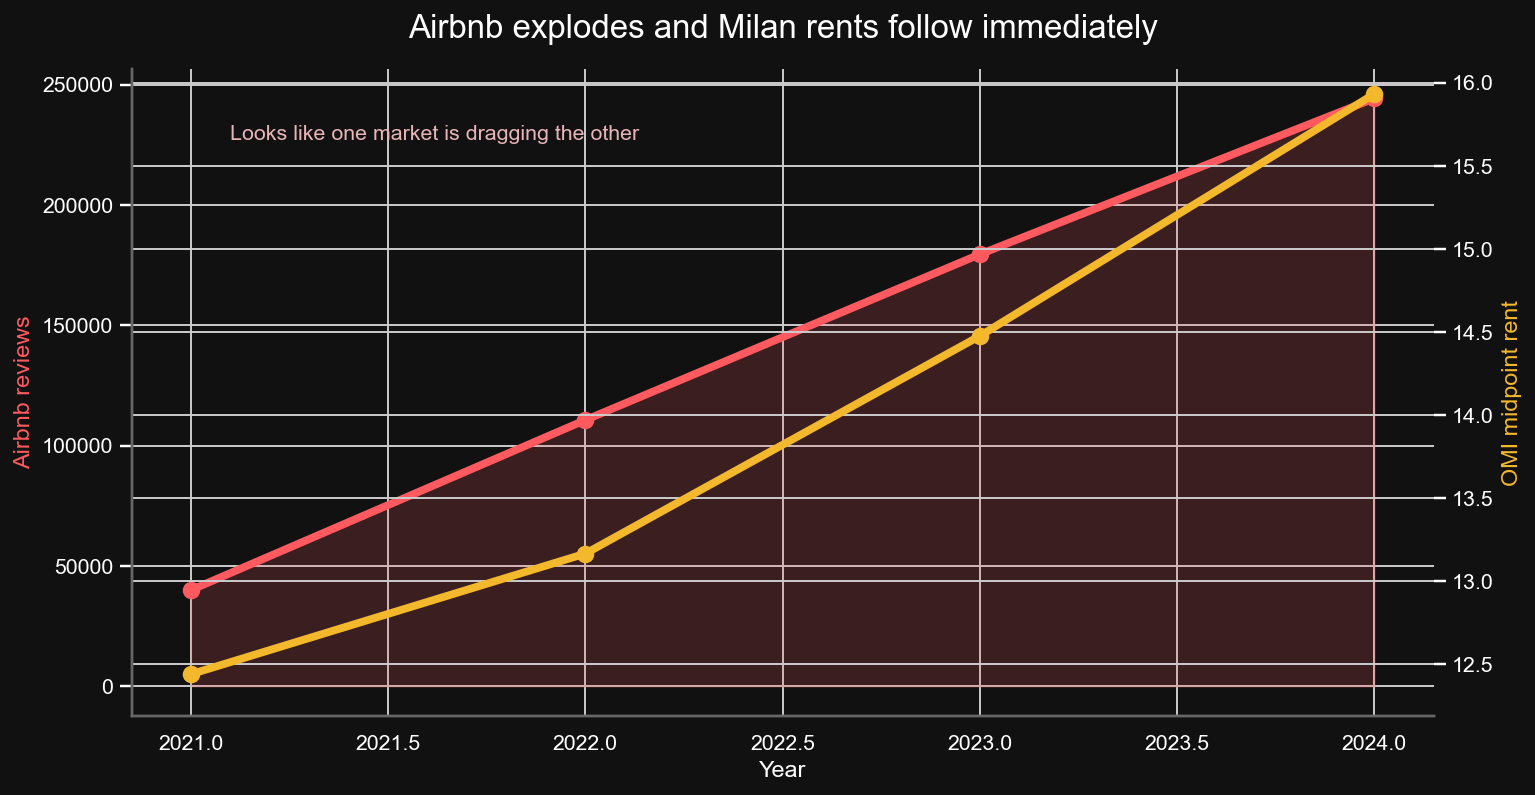

Saved: c:\Users\miche\University\Material\Data Science\Data Visualization\Project\src\io\plots\black_hat_visualization.png


In [14]:
# Rebuild the citywide yearly series directly from the cleaned original tables.
reviews_yearly = reviews_clean.groupby("year", as_index=False).agg(review_count=("listing_id", "size"))
reviews_yearly = reviews_yearly[reviews_yearly["year"].between(2018, 2024)].copy()
omi_yearly_black_hat = omi_clean.groupby("Year", as_index=False).agg(rent_mid=("rent_mid", "mean"))
omi_yearly_black_hat = omi_yearly_black_hat[omi_yearly_black_hat["Year"].between(2018, 2024)].copy()
black_hat = reviews_yearly.merge(omi_yearly_black_hat, left_on="year", right_on="Year", how="inner")
black_hat = black_hat[black_hat["year"].between(2021, 2024)].copy()

# Create the dual axis chart with aggressive styling choices.
fig, ax1 = plt.subplots(figsize=(12, 6), facecolor="#111111")
ax1.set_facecolor("#111111")
ax2 = ax1.twinx()

# Plot Airbnb activity with a dramatic color and thick stroke.
ax1.plot(black_hat["year"], black_hat["review_count"], color=palette["coral"], marker="o", linewidth=4, markersize=8)
ax1.fill_between(black_hat["year"], black_hat["review_count"], color=palette["coral"], alpha=0.18)

# Plot rent on a tightly truncated scale to exaggerate movement.
ax2.plot(black_hat["year"], black_hat["rent_mid"], color=palette["gold"], marker="o", linewidth=4, markersize=8)
ax2.set_ylim(black_hat["rent_mid"].min() - 0.25, black_hat["rent_mid"].max() + 0.15)

# Style the axes to intensify the impression of a causal surge.
ax1.set_title("Airbnb explodes and Milan rents follow immediately", fontsize=17, color=palette["white"], pad=16)
ax1.set_xlabel("Year", color=palette["white"])
ax1.set_ylabel("Airbnb reviews", color=palette["coral"])
ax2.set_ylabel("OMI midpoint rent", color=palette["gold"])
ax1.tick_params(colors=palette["white"])
ax2.tick_params(colors=palette["white"])
for spine in ax1.spines.values():
    spine.set_color("#666666")
for spine in ax2.spines.values():
    spine.set_color("#666666")

# Add a suggestive annotation that overstates the visual evidence.
ax1.text(2021.1, black_hat["review_count"].max() * 0.93, "Looks like one market is dragging the other", color=palette["duomo_pink"], fontsize=11)

# Export the intentionally misleading figure.
black_hat_path = PLOTS_DIR / "black_hat_visualization.png"
fig.savefig(black_hat_path, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved:", black_hat_path)


This figure is persuasive precisely because it is irresponsible. By dropping the pre 2021 context, it erases the pandemic break and makes the rebound look like a seamless acceleration. By using dual axes and a truncated rent scale, it visually amplifies alignment between two variables that live on completely different magnitudes. The title then does the final manipulative step, because it turns a visual coincidence into a causal slogan.

The lesson is useful for the project report. Ethical problems in visualization often come from emphasis and framing rather than fabricated data. A reader can be pushed toward a strong conclusion even when every point on the chart is technically real.


# 6) White Hat Visualization

The white hat view keeps the same underlying comparison but redesigns it to be transparent. Instead of relying on two vertical scales, it normalizes both series to a common baseline and restores the full overlapping period. This approach gives up some dramatic effect, but it gives the reader a fair chance to judge how similar or dissimilar the trajectories really are.

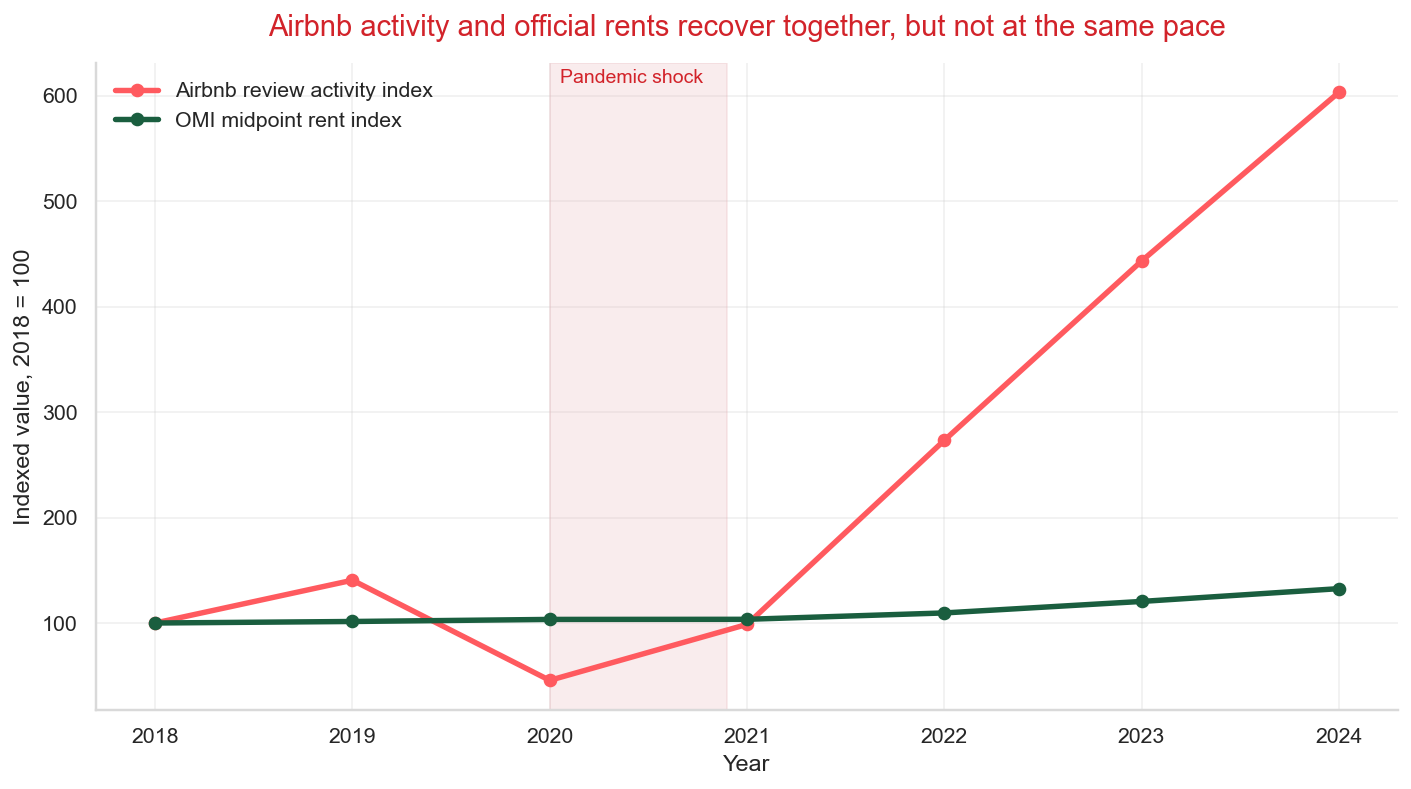

Saved: c:\Users\miche\University\Material\Data Science\Data Visualization\Project\src\io\plots\white_hat_visualization.png


In [15]:
# Rebuild the citywide overlap table directly from the cleaned original tables.
reviews_yearly = reviews_clean.groupby("year", as_index=False).agg(review_count=("listing_id", "size"))
reviews_yearly = reviews_yearly[reviews_yearly["year"].between(2018, 2024)].copy()
omi_yearly_white_hat = omi_clean.groupby("Year", as_index=False).agg(rent_mid=("rent_mid", "mean"))
omi_yearly_white_hat = omi_yearly_white_hat[omi_yearly_white_hat["Year"].between(2018, 2024)].copy()
white_hat = reviews_yearly.merge(omi_yearly_white_hat, left_on="year", right_on="Year", how="inner")
white_hat["reviews_index"] = white_hat["review_count"] / white_hat["review_count"].iloc[0] * 100
white_hat["rent_index"] = white_hat["rent_mid"] / white_hat["rent_mid"].iloc[0] * 100

# Plot both series on the same indexed scale for an honest comparison.
fig, ax = plt.subplots(figsize=(12, 6), facecolor=palette["white"])
ax.plot(white_hat["year"], white_hat["reviews_index"], color=palette["coral"], marker="o", linewidth=2.8, label="Airbnb review activity index")
ax.plot(white_hat["year"], white_hat["rent_index"], color=palette["green"], marker="o", linewidth=2.8, label="OMI midpoint rent index")

# Keep the context of the pandemic visible without turning it into drama.
ax.axvspan(2020, 2020.9, color=palette["duomo_pink"], alpha=0.25)
ax.text(2020.05, ax.get_ylim()[1] * 0.97, "Pandemic shock", color=palette["red"], fontsize=10)

# Use direct labels and a neutral title to reduce interpretive pressure.
ax.set_title("Airbnb activity and official rents recover together, but not at the same pace", fontsize=15, color=palette["red"], pad=14)
ax.set_xlabel("Year")
ax.set_ylabel("Indexed value, 2018 = 100")
ax.legend(frameon=False, loc="upper left")
ax.grid(alpha=0.25)

# Export the transparent figure to the project io folder.
white_hat_path = PLOTS_DIR / "white_hat_visualization.png"
fig.savefig(white_hat_path, bbox_inches="tight")
plt.show()
print("Saved:", white_hat_path)


The white hat version still supports a substantive interpretation, but it does so more carefully. The reader can see that Airbnb review activity rebounds more sharply than official rents, and that the two lines become closer again after the pandemic disruption. What the chart does not do is overpromise. It does not claim that the rent series proves platform causality, only that the two dynamics deserve to be studied together.

This difference between the black hat and white hat designs is valuable beyond the chart itself. It clarifies the ethical standard of the whole project. Good visualization is not only about making patterns visible. It is about choosing forms that do not pressure the reader into conclusions that the data cannot fully sustain.

# 7) Data Preparation for further analysis

Once the project moves toward dashboard construction,a new step becomes necessary: dedicated derivative tables should be created for the exact analytical grain of the future visualizations.

In practical terms, this means separating zone level snapshots, yearly trend tables, and category level composition tables. The advantage is methodological as much as technical. Each visualization can then rely on a dataset whose rows match the analytical unit of the chart, which reduces duplication, avoids overcounting, and makes filtering more reliable. The following code therefore acts as the bridge between the present notebook and the next phase of Tableau oriented analysis.


In [16]:
# Create the mapped listings table only at the dashboard preparation stage.
listings_mapped = listings_clean.copy()
listings_mapped["omi_zona"] = listings_mapped["neighbourhood"].map(NEIGHBOURHOOD_TO_ZONA)

# Build a 2024 zone snapshot for KPI cards, maps, and filtering.
omi_latest = omi_clean[omi_clean["Year"].eq(2024)].groupby("Zona", as_index=False).agg(omi_loc_min_2024=("Loc_min", "mean"), omi_loc_max_2024=("Loc_max", "mean"), omi_level_avg_2024=("rent_mid", "mean"))
tableau_zone_snapshot_2024 = listings_mapped.groupby("omi_zona", as_index=False).agg(listings_count=("id", "nunique"), avg_airbnb_price=("price", "mean"), median_airbnb_price=("price", "median"), number_of_reviews=("number_of_reviews", "sum"), number_of_reviews_ltm=("number_of_reviews_ltm", "sum"), distinct_hosts=("host_id", "nunique"), avg_latitude=("latitude", "mean"), avg_longitude=("longitude", "mean"), entire_home_share=("is_entire_home", "mean"), professional_host_share=("is_professional_host", "mean"))
tableau_zone_snapshot_2024 = tableau_zone_snapshot_2024.merge(omi_latest, left_on="omi_zona", right_on="Zona", how="left").drop(columns=["Zona"])

# Aggregate reviews by mapped zone and year for trend analysis.
reviews_zone_year = reviews_clean.merge(listings_mapped[["id", "omi_zona"]], left_on="listing_id", right_on="id", how="left")
reviews_zone_year = reviews_zone_year.dropna(subset=["omi_zona"]).groupby(["omi_zona", "year"], as_index=False).agg(review_count=("listing_id", "size"))

# Aggregate official OMI min and max values by zone and year.
omi_zone_year = omi_clean.groupby(["Zona", "Year"], as_index=False).agg(omi_loc_min_avg=("Loc_min", "mean"), omi_loc_max_avg=("Loc_max", "mean"), omi_level_avg=("rent_mid", "mean"))
tableau_zone_year_trends = omi_zone_year.merge(reviews_zone_year, left_on=["Zona", "Year"], right_on=["omi_zona", "year"], how="left")
tableau_zone_year_trends["review_count"] = tableau_zone_year_trends["review_count"].fillna(0)
tableau_zone_year_trends["omi_zona"] = tableau_zone_year_trends["Zona"]
tableau_zone_year_trends["year"] = tableau_zone_year_trends["Year"]
tableau_zone_year_trends = tableau_zone_year_trends[["omi_zona", "year", "review_count", "omi_loc_min_avg", "omi_loc_max_avg", "omi_level_avg"]].sort_values(["omi_zona", "year"]).reset_index(drop=True)

# Compute year over year growth rates for the three dashboard trend lines.
for source_col, growth_col in [("review_count", "reviews_growth_rate"), ("omi_loc_min_avg", "omi_min_growth_rate"), ("omi_loc_max_avg", "omi_max_growth_rate")]:
    previous = tableau_zone_year_trends.groupby("omi_zona")[source_col].shift(1)
    tableau_zone_year_trends[growth_col] = np.where((previous.isna()) | (previous.eq(0)), np.nan, ((tableau_zone_year_trends[source_col] - previous) / previous) * 100)

# Summarize Airbnb listing types by zone for composition charts.
tableau_zone_listing_types = listings_mapped.groupby(["omi_zona", "room_type"], as_index=False).agg(listing_count=("id", "nunique"))
zone_listing_totals = tableau_zone_listing_types.groupby("omi_zona")["listing_count"].transform("sum")
tableau_zone_listing_types["listing_share"] = tableau_zone_listing_types["listing_count"] / zone_listing_totals

# Summarize retained OMI housing typologies by zone for composition charts.
tableau_zone_housing_types = omi_clean.groupby(["Zona", "Descr_Tipologia"], as_index=False).agg(omi_loc_min_avg=("Loc_min", "mean"), omi_loc_max_avg=("Loc_max", "mean"), omi_level_avg=("rent_mid", "mean"), rows=("rent_mid", "size"))
tableau_zone_housing_types = tableau_zone_housing_types.rename(columns={"Zona": "omi_zona"})

# Export CSV tables to the results folder and the combined workbook to the tableau folder.
tableau_exports = {
    "tableau_zone_snapshot_2024": tableau_zone_snapshot_2024,
    "tableau_zone_year_trends": tableau_zone_year_trends,
    "tableau_zone_listing_types": tableau_zone_listing_types,
    "tableau_zone_housing_types": tableau_zone_housing_types,
}
tableau_workbook_path = TABLEAU_DIR / "tableau_dashboard_data.xlsx"
save_tableau_workbook(tableau_exports, tableau_workbook_path)
for name, frame in tableau_exports.items():
    csv_path = RESULTS_DIR / f"{name}.csv"
    frame.to_csv(csv_path, index=False)
    print("Saved:", csv_path)



Saved: c:\Users\miche\University\Material\Data Science\Data Visualization\Project\src\io\tableau\tableau_dashboard_data.xlsx
Saved: c:\Users\miche\University\Material\Data Science\Data Visualization\Project\src\io\results\tableau_zone_snapshot_2024.csv
Saved: c:\Users\miche\University\Material\Data Science\Data Visualization\Project\src\io\results\tableau_zone_year_trends.csv
Saved: c:\Users\miche\University\Material\Data Science\Data Visualization\Project\src\io\results\tableau_zone_listing_types.csv
Saved: c:\Users\miche\University\Material\Data Science\Data Visualization\Project\src\io\results\tableau_zone_housing_types.csv
